In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('train_dataset.csv')

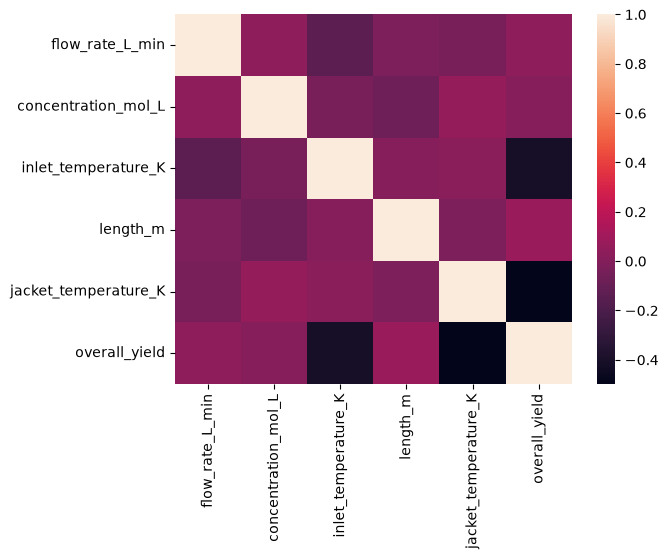

In [16]:
# df = df[df["overall_yield"] != 0]
corr_matrix = df.corr()
sns.heatmap(corr_matrix)
plt.show()

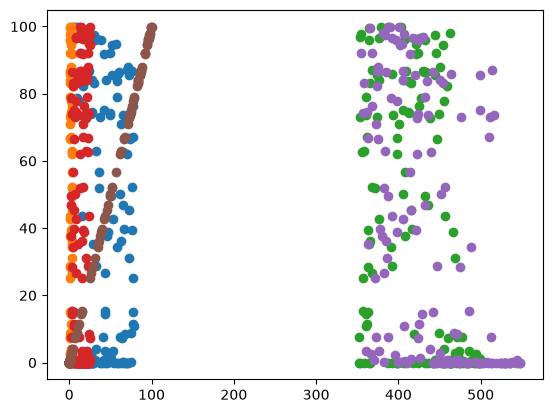

In [17]:
for i in df.columns:
    plt.scatter(df[i], df["overall_yield"])

In [18]:
df.columns[0]

'flow_rate_L_min'

IndexError: index 6 is out of bounds for axis 0 with size 6

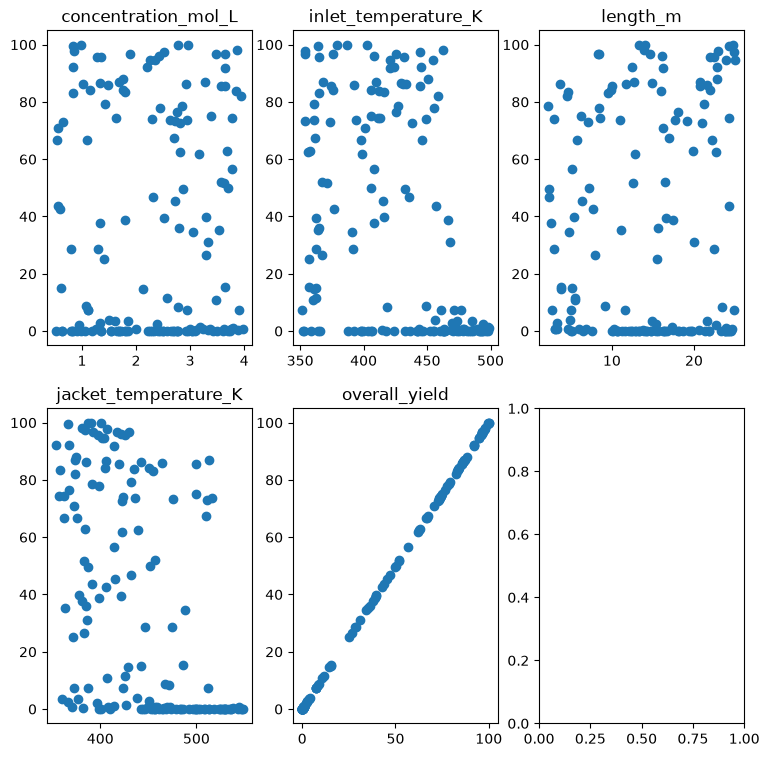

In [19]:
fig = plt.figure(figsize=(9, 9))
rows, cols = 2,3
for i in range(1, rows * cols + 1):
    # random_idx = torch.randint(0, len(train_data), size=[1]).item()
    # img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.scatter(df[df.columns[i]], df["overall_yield"])
    plt.title(df.columns[i])
    # plt.axis(False);

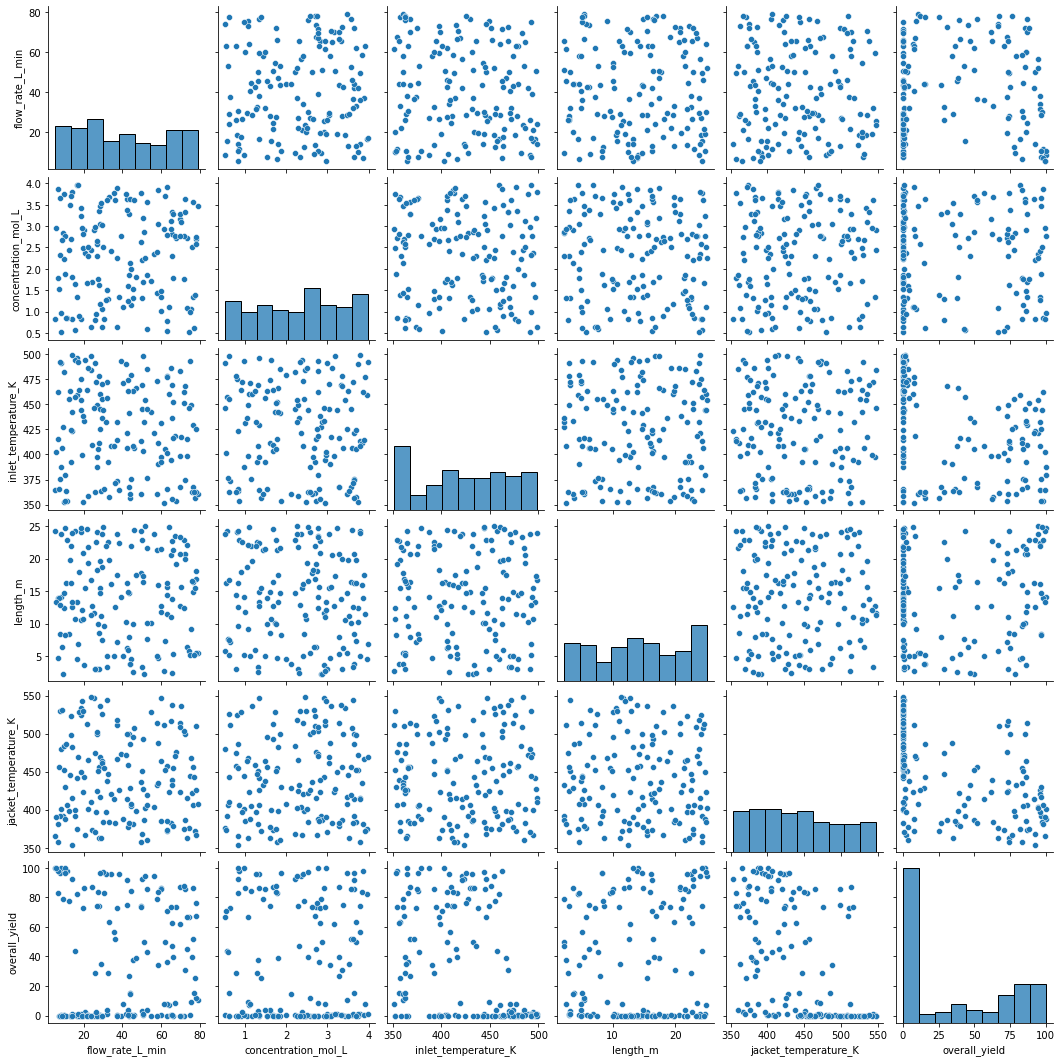

In [ ]:
sns.pairplot(df)

<AxesSubplot:xlabel='length_m', ylabel='overall_yield'>

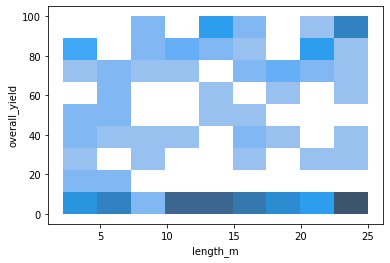

In [ ]:
sns.histplot(data=df, x=df.length_m, y = df.overall_yield)

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
import pandas as pd

# Load dataset
df = pd.read_csv("train_dataset.csv")

# Features and target
X = df.drop("overall_yield", axis=1)
y = df["overall_yield"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create model
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.2,
    max_depth=4,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R² Score: 0.750603140652061
RMSE: 20.941351247029047


In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
import pandas as pd

# Load dataset
df = pd.read_csv("train_dataset.csv")

# Features and target
X = df.drop("overall_yield", axis=1)
y = df["overall_yield"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create model
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.03,
    depth=4,              # shallow — small dataset, avoid overfitting
    l2_leaf_reg=5,         # extra regularization for small N
    loss_function="RMSE",
    random_state=42,
    verbose=False
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R² Score: 0.7251882978387515
RMSE: 21.982486859984792


In [ ]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
import pandas as pd

# Load dataset
df = pd.read_csv("train_dataset.csv")

# Features and target
X = df.drop("overall_yield", axis=1)
y = df["overall_yield"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=8,
    min_child_samples=15,
    subsample=0.8,
    colsample_bytree=0.8,
    verbosity=-1,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R² Score: 0.7065877486677645
RMSE: 22.71424642134109


In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
import pandas as pd

# Load dataset
df = pd.read_csv("train_dataset.csv")

# Features and target
X = df.drop("overall_yield", axis=1)
y = df["overall_yield"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = ExtraTreesRegressor(
    n_estimators=1000,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=False,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R² Score: 0.6646011082411094
RMSE: 24.28510708335933


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Fold scores:", scores)
print("Mean R²:", scores.mean())
print("Std:", scores.std())

Fold scores: [0.70007187 0.79263588 0.74832531 0.74662369 0.32388639]
Mean R²: 0.6623086280988538
Std: 0.17172580915455415


In [ ]:
from sklearn.model_selection import cross_val_score

rmse = -cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

print("Mean RMSE:", rmse.mean())

Mean RMSE: 20.236568832456147


In [ ]:
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.metrics import make_scorer, root_mean_squared_error
import numpy as np

# Replace 'model' with your trained model instance if needed
cv = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

# R²
r2_scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# RMSE
rmse_scores = -cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

print("=" * 50)
print(f"Mean R²   : {np.mean(r2_scores):.4f}")
print(f"Std R²    : {np.std(r2_scores):.4f}")
print(f"Best R²   : {np.max(r2_scores):.4f}")
print(f"Worst R²  : {np.min(r2_scores):.4f}")
print()
print(f"Mean RMSE : {np.mean(rmse_scores):.4f}")
print(f"Std RMSE  : {np.std(rmse_scores):.4f}")
print(f"Best RMSE : {np.min(rmse_scores):.4f}")
print(f"Worst RMSE: {np.max(rmse_scores):.4f}")
print("=" * 50)

Mean R²   : 0.7204
Std R²    : 0.0833
Best R²   : 0.8663
Worst R²  : 0.4406

Mean RMSE : 19.6992
Std RMSE  : 2.5037
Best RMSE : 14.6062
Worst RMSE: 26.0194


In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    model, X, y,
    n_repeats=20,
    random_state=42,
    scoring="r2"
)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
}).sort_values("Importance", ascending=False)

print(importance)

                Feature  Importance
4  jacket_temperature_K    0.886482
2   inlet_temperature_K    0.720881
0       flow_rate_L_min    0.189643
3              length_m    0.112274
1   concentration_mol_L    0.021833


In [ ]:
from sklearn.ensemble import StackingRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import RepeatedKFold, cross_val_score
import numpy as np

# Base models
estimators = [
    ("extra", ExtraTreesRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    )),
    ("cat", CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=4,
        verbose=0,
        random_seed=42
    )),
    ("xgb", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ))
]

# Stacking model
model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=5,
    n_jobs=-1
)

# Evaluation
cv = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

r2 = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

rmse = -cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

print("Mean R² :", np.mean(r2))
print("Std R²  :", np.std(r2))
print("Mean RMSE:", np.mean(rmse))

Mean R² : 0.7273595739395495
Std R²  : 0.1011593541958957
Mean RMSE: 19.31598125429142


In [ ]:
import pandas as pd
import numpy as np

from sklearn.ensemble import (
    ExtraTreesRegressor,
    StackingRegressor
)
from sklearn.linear_model import Ridge
from sklearn.model_selection import RepeatedKFold, cross_val_score

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# =========================
# Load Dataset
# =========================
df = pd.read_csv("train_dataset.csv")

X = df.drop("overall_yield", axis=1)
y = df["overall_yield"]

# =========================
# Base Models
# =========================

extra = ExtraTreesRegressor(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

cat = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=0
)

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

estimators = [
    ("extra", extra),
    ("cat", cat),
    ("xgb", xgb)
]

# =========================
# Stacking Model
# =========================

model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    passthrough=True,
    n_jobs=-1
)

# =========================
# Cross Validation
# =========================

cv = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

r2_scores = cross_val_score(
    model,
    X,
    y,
    scoring="r2",
    cv=cv,
    n_jobs=-1
)

rmse_scores = -cross_val_score(
    model,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

print("=" * 50)
print(f"Mean R²   : {np.mean(r2_scores):.4f}")
print(f"Std R²    : {np.std(r2_scores):.4f}")
print(f"Best R²   : {np.max(r2_scores):.4f}")
print(f"Worst R²  : {np.min(r2_scores):.4f}")
print()
print(f"Mean RMSE : {np.mean(rmse_scores):.4f}")
print(f"Std RMSE  : {np.std(rmse_scores):.4f}")
print(f"Best RMSE : {np.min(rmse_scores):.4f}")
print(f"Worst RMSE: {np.max(rmse_scores):.4f}")
print("=" * 50)

Mean R²   : 0.6580
Std R²    : 0.1077
Best R²   : 0.8460
Worst R²  : 0.3365

Mean RMSE : 21.7387
Std RMSE  : 2.8900
Best RMSE : 15.7742
Worst RMSE: 28.3796
